## Tratamento dos dados e interpolação

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df = pd.read_csv("DI_Historico_Consolidado_20210101_a_20260227.csv", sep=";")
df['Data_Referencia'] = pd.to_datetime(df['Data_Referencia'], format='%d/%m/%Y')
df['Maturity'] = pd.to_datetime(df['Maturity'], format='%d/%m/%Y')

# Calcular NDU (Dias Úteis) e Taxa Contínua
dates_ref = df['Data_Referencia'].values.astype('datetime64[D]')
dates_mat = df['Maturity'].values.astype('datetime64[D]')
df['NDU'] = np.busday_count(dates_ref, dates_mat)

# Filtra vencimentos no mesmo dia e calcula a taxa
df = df[df['NDU'] > 0].copy()
df['Taxa'] = ((100000.0 / df['AdjstdQt']) ** (252.0 / df['NDU']) - 1) * 100

# DEFINIR VÉRTICES MENSAIS FIXOS (M1 até M166)
# Assumindo 21 dias úteis para cada mês padrão
meses = list(range(1, 167))
fixed_ndus = [m * 21 for m in meses]
fixed_labels = [f'M{m}' for m in meses]

# INTERPOLAÇÃO FLAT FORWARD 252 (Padrão Oficial da B3) para os meses que não têm dados exatos
interpolated_data = []

for date, group in df.groupby('Data_Referencia'):
    # Remove eventuais NDUs duplicados e ordena
    group = group.drop_duplicates(subset=['NDU']).sort_values('NDU')
    x = group['NDU'].values
    y = group['Taxa'].values
    
    if len(x) > 1:
        rates = []
        for target_ndu in fixed_ndus:
            # Regras de contorno: se estiver fora dos limites, usamos a ponta (Flat)
            if target_ndu <= x[0]:
                rates.append(y[0])
            elif target_ndu >= x[-1]:
                rates.append(y[-1])
            else:
                # Interpolação no miolo da curva
                idx_post = np.searchsorted(x, target_ndu)
                idx_ant = idx_post - 1
                
                du_ant, du_post = x[idx_ant], x[idx_post]
                L_ant, L_post = y[idx_ant], y[idx_post]
                
                # Matemática Oficial da B3
                part_post = (1 + L_post / 100) ** (du_post / 252)
                part_ant = (1 + L_ant / 100) ** (du_ant / 252)
                
                inner = part_post / part_ant
                exponent = (target_ndu - du_ant) / (du_post - du_ant)
                
                i_interp = (((inner ** exponent) * part_ant) ** (252 / target_ndu) - 1) * 100
                rates.append(i_interp)
                
        # Guarda o dia preenchido
        row = {'Data_Referencia': date}
        for label, rate in zip(fixed_labels, rates):
            row[label] = rate
        interpolated_data.append(row)

# Montar a Matriz Pivotada Final
df_pivot = pd.DataFrame(interpolated_data).set_index('Data_Referencia').dropna()

df_pivot.to_excel('Curva_DI_Interpolada_Flat_Forward_252.xlsx')
df_pivot 


,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M157,M158,M159,M160,M161,M162,M163,M164,M165,M166
Data_Referencia,,,,,,,,,,,,,,,,,,,,,
2021-01-04,1.91,1.83,1.88,1.88,1.95,2.01,2.09,2.23,2.35,2.46,...,7.15,7.16,7.16,7.17,7.17,7.18,7.18,7.19,7.19,7.20
2021-01-05,1.90,1.85,1.90,1.90,1.98,2.03,2.12,2.27,2.40,2.51,...,7.21,7.21,7.22,7.22,7.23,7.23,7.24,7.24,7.25,7.25
2021-01-06,1.88,1.84,1.89,1.91,2.00,2.07,2.16,2.32,2.44,2.56,...,7.40,7.41,7.41,7.42,7.42,7.43,7.43,7.44,7.44,7.45
2021-01-07,1.88,1.84,1.90,1.93,2.01,2.07,2.17,2.34,2.48,2.61,...,7.71,7.71,7.72,7.72,7.73,7.73,7.74,7.74,7.75,7.75
2021-01-08,1.87,1.84,1.90,1.95,2.04,2.13,2.24,2.42,2.55,2.70,...,7.75,7.75,7.76,7.76,7.77,7.77,7.78,7.78,7.79,7.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-23,14.76,13.92,13.72,13.61,13.53,13.45,13.30,13.09,12.90,12.74,...,12.83,12.83,12.83,12.83,12.83,12.83,12.82,12.82,12.82,12.82
2026-02-24,14.76,13.86,13.70,13.58,13.51,13.43,13.28,13.07,12.88,12.72,...,12.78,12.78,12.78,12.78,12.78,12.78,12.78,12.78,12.78,12.78
2026-02-25,14.74,13.79,13.68,13.56,13.49,13.42,13.27,13.06,12.88,12.71,...,12.73,12.73,12.73,12.73,12.73,12.73,12.73,12.73,12.73,12.73


## O PCA

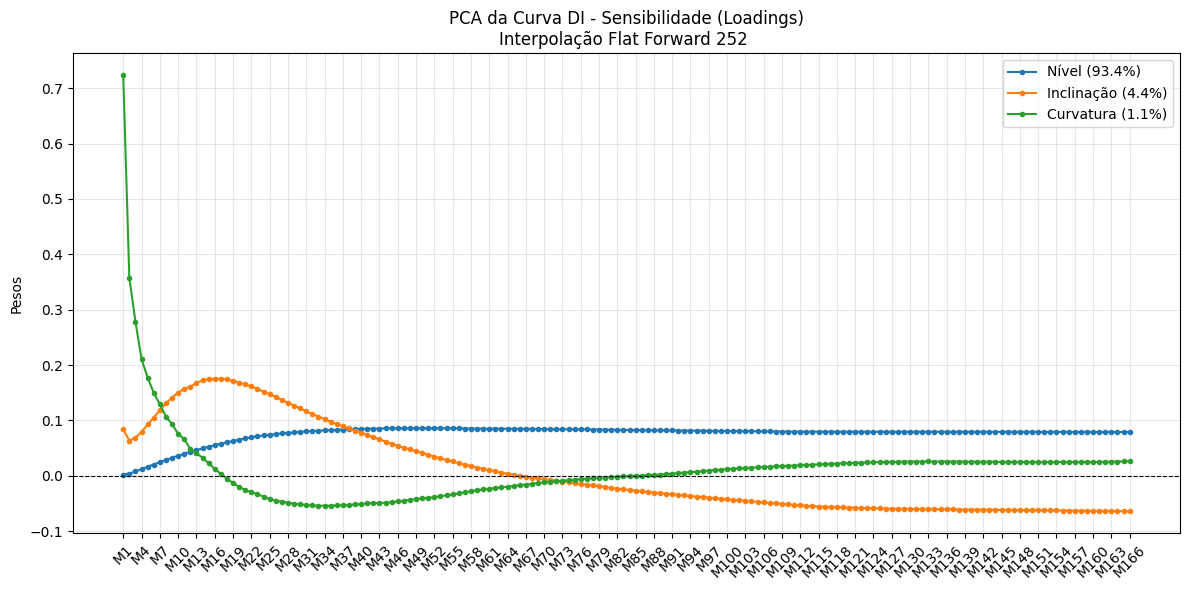

Dimensão da matriz final: 1282 dias operacionais x 166 vértices mensais


In [33]:

###################################### PCA #######################################
# Nivel: Sensibilidade a variações paralelas (shift) da curva
# Inclinação: Sensibilidade a variações de inclinação (steepening/flattening)
# Curvatura: Sensibilidade a variações de curvatura (butterfly)

# O PCA usa a VARIAÇÃO DIÁRIA (Delta y) da matriz interpolada
df_diff = df_pivot.diff().dropna()

pca = PCA(n_components=3)
factors = pca.fit_transform(df_diff)
var_expl = pca.explained_variance_ratio_ * 100

# Plotar os Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['Nível', 'Inclinação', 'Curvatura'], index=fixed_labels)

plt.figure(figsize=(12, 6))
# Usando range para o eixo X não ficar com texto embolado
plt.plot(range(len(loadings)), loadings['Nível'], marker='.', label=f'Nível ({var_expl[0]:.1f}%)')
plt.plot(range(len(loadings)), loadings['Inclinação'], marker='.', label=f'Inclinação ({var_expl[1]:.1f}%)')
plt.plot(range(len(loadings)), loadings['Curvatura'], marker='.', label=f'Curvatura ({var_expl[2]:.1f}%)')

# Ajustar os rótulos do eixo X (mostrando de 3 em 3 meses para ficar limpo)
plt.xticks(ticks=range(0, len(loadings), 3), labels=fixed_labels[::3], rotation=45)
plt.title('PCA da Curva DI - Sensibilidade (Loadings)\nInterpolação Flat Forward 252 ')
plt.ylabel('Pesos')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar e mostrar
import os   
if not os.path.exists('Figures'):
    os.makedirs('Figures')
plt.savefig('Figures/pca_loadings.png')
plt.show()

print(f"Dimensão da matriz final: {df_pivot.shape[0]} dias operacionais x {df_pivot.shape[1]} vértices mensais")

## Resíduo e Z-score

Calculando o Preço Justo e extraindo o Spread...


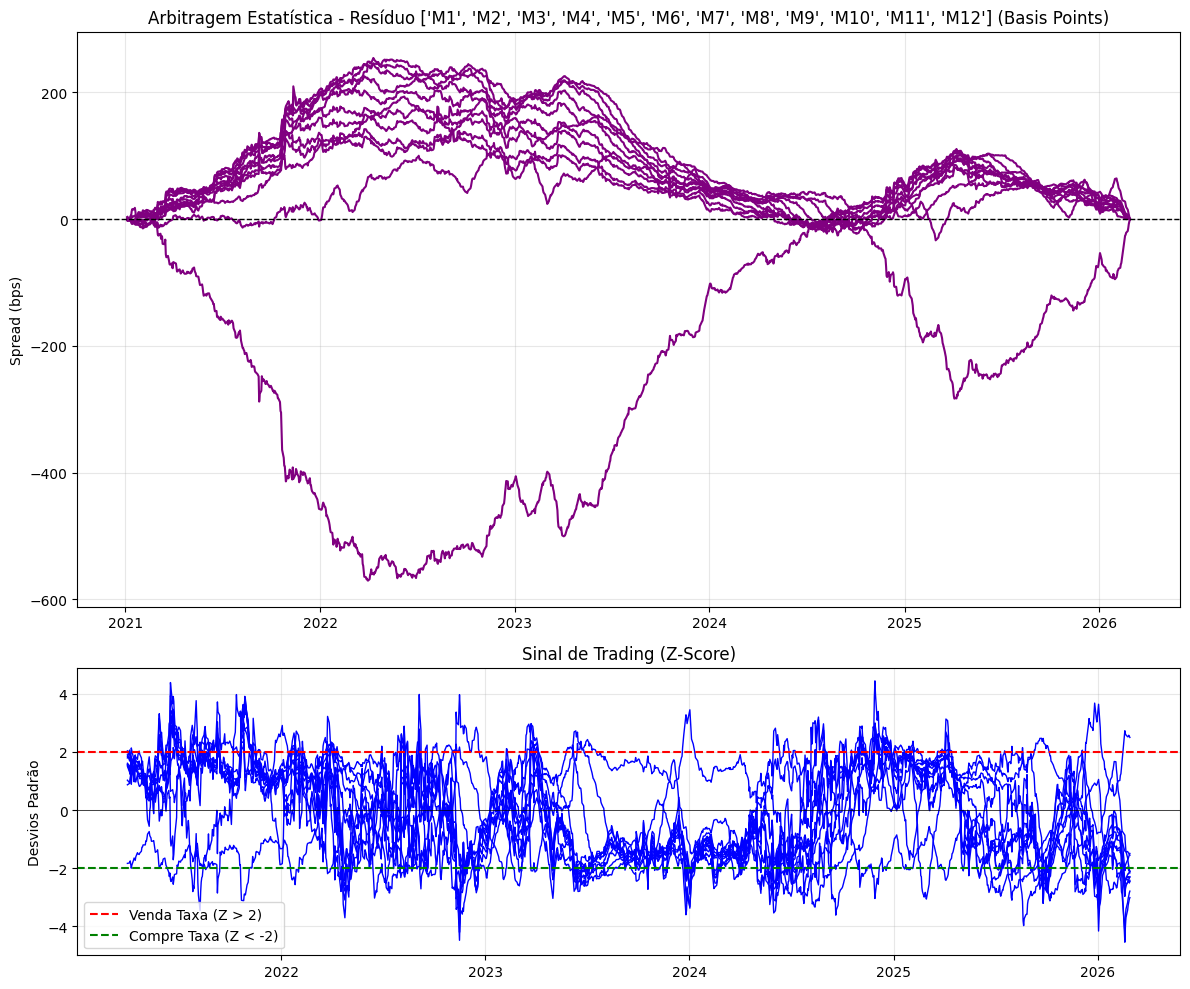

In [34]:
# EXTRAÇÃO DO RESÍDUO (A ANOMALIA)
print("Calculando o Preço Justo e extraindo o Spread...")

df_pca = df_pivot.copy()
# Reconstruir variação teórica (usando APENAS os 3 fatores)
theo_diff = pca.inverse_transform(factors)
df_theo_diff = pd.DataFrame(theo_diff, index=df_diff.index, columns=df_diff.columns)

# Reconstruir a Taxa Teórica Acumulada
df_theo_rates = df_theo_diff.cumsum() + df_pca.iloc[0]

# Calcular o Spread (Real - Teórico)
df_real_rates = df_pca.iloc[1:]
df_spreads = df_real_rates - df_theo_rates

# Analisar o os vertices e M1 a M12
vertices_alvo = ['M1','M2','M3','M4','M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
spread_alvo = df_spreads[vertices_alvo]

# Z-Score (Janela Móvel de 60 dias)
window = 60
z_score = (spread_alvo - spread_alvo.rolling(window).mean()) / spread_alvo.rolling(window).std()

# Plotar Arbitragem (Gráfico 2)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(spread_alvo.index, spread_alvo.values * 100, color='purple', linewidth=1.5)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title(f'Arbitragem Estatística - Resíduo {vertices_alvo} (Basis Points)')
ax1.set_ylabel('Spread (bps)')
ax1.grid(True, alpha=0.3)

ax2.plot(z_score.index, z_score.values, color='blue', linewidth=1)
ax2.axhline(2, color='red', linestyle='--', label='Venda Taxa (Z > 2)')
ax2.axhline(-2, color='green', linestyle='--', label='Compre Taxa (Z < -2)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Sinal de Trading (Z-Score)')
ax2.set_ylabel('Desvios Padrão')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/arbitragem_spread.png')
plt.show()

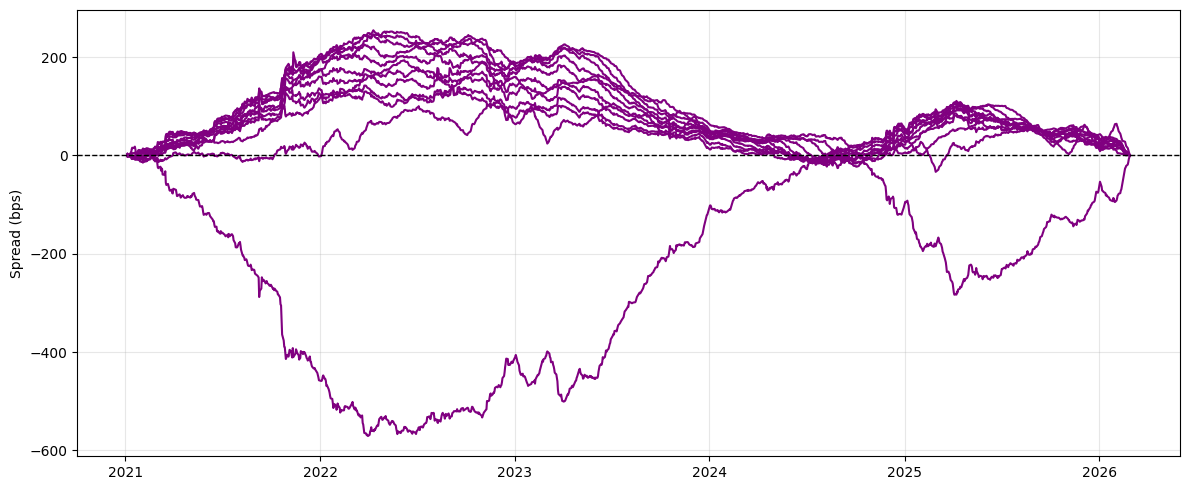

In [35]:
# Plotar Arbitragem (Gráfico 2 - Spread)
plt.figure(figsize=(12, 5))
plt.plot(spread_alvo.index, spread_alvo.values * 100, color='purple', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
#plt.title(f'Arbitragem Estatística - Resíduo {vertice_alvo} (Basis Points)')
plt.ylabel('Spread (bps)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figures/arbitragem_spread.png')
plt.show()

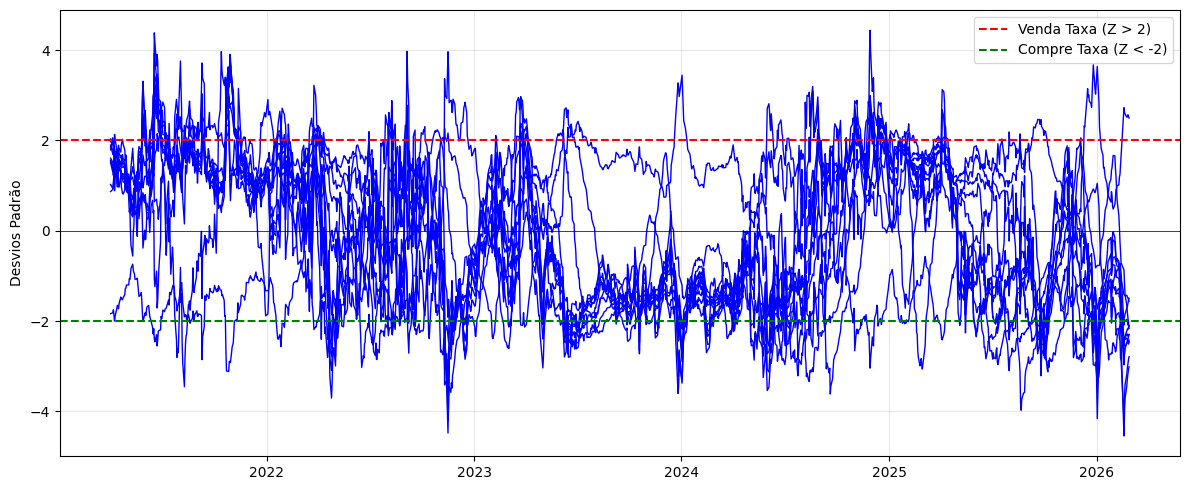

In [36]:

plt.figure(figsize=(12, 5))
plt.plot(z_score.index, z_score.values, color='blue', linewidth=1)
plt.axhline(2, color='red', linestyle='--', label='Venda Taxa (Z > 2)')
plt.axhline(-2, color='green', linestyle='--', label='Compre Taxa (Z < -2)')
plt.axhline(0, color='black', linewidth=0.5)
#plt.title('Sinal de Trading (Z-Score)')
plt.ylabel('Desvios Padrão')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figures/arbitragem_zscore.png')
plt.show()

## Plots genéricos

## Tradando

In [37]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

vertices = [f'M{i}' for i in range(1, 167)]
df_pca = df_pivot[vertices].dropna()

# Separar o "Passado" (Treino) e o "Hoje" (O dia novo que queremos testar)
# Vamos fingir que o penúltimo dia foi o último fechamento, e a última linha é o "dia de hoje"
df_historico = df_pca.iloc[:-1]
dia_novo = df_pca.iloc[-1:]  # Última linha (ex: 2022-05-05)
data_hoje = dia_novo.index[0].strftime('%d/%m/%Y')

print(f"--- SIMULADOR DE MESA DE OPERAÇÕES ---")
print(f"Treinando o modelo com dados até o dia anterior...")
print(f"Analisando o pregão de hoje: {data_hoje}\n")

# Treinar o modelo PCA apenas com o histórico
df_diff_hist = df_historico.diff().dropna()
pca = PCA(n_components=3)
pca.fit(df_diff_hist)

# Reconstruir a história para ter a base do Z-Score
fatores_hist = pca.transform(df_diff_hist)
diff_teorica_hist = pca.inverse_transform(fatores_hist)
taxas_teoricas_hist = pd.DataFrame(diff_teorica_hist, index=df_diff_hist.index, columns=df_diff_hist.columns).cumsum() + df_historico.iloc[0]

spreads_hist = df_historico.iloc[1:] - taxas_teoricas_hist
media_spread_60d = spreads_hist.iloc[-60:].mean()  # Média móvel dos últimos 60 dias do histórico
std_spread_60d = spreads_hist.iloc[-60:].std()     # Desvio padrão dos últimos 60 dias

# O ALGORITMO RODANDO "HOJE" (Tempo Real)
# A variação de hoje é a taxa de hoje menos a taxa de ontem
delta_y_hoje = dia_novo.values - df_historico.iloc[-1].values

# Calcular os 3 Fatores de hoje
fatores_hoje = pca.transform(delta_y_hoje)

# Reconstruir a variação matemática pura de hoje
delta_teorico_hoje = pca.inverse_transform(fatores_hoje)

# Taxa Teórica de Hoje = Taxa Real de Ontem + Variação Teórica de Hoje
taxa_teorica_hoje = df_historico.iloc[-1].values + delta_teorico_hoje

# Spread de Hoje = Taxa Real da B3 de Hoje - Taxa Teórica de Hoje
spread_hoje = dia_novo.values - taxa_teorica_hoje

# Z-Score de Hoje = (Spread Hoje - Média 60d do Passado) / Desvio 60d do Passado
z_score_hoje = (spread_hoje[0] - media_spread_60d.values) / std_spread_60d.values

# 6. Montar o Relatório do Radar
relatorio = pd.DataFrame({
    'Taxa B3 (%)': dia_novo.values[0],
    'Taxa Teórica (%)': taxa_teorica_hoje[0],
    'Spread (bps)': spread_hoje[0] * 100,
    'Z-Score': z_score_hoje
}, index=vertices)

# Identificar os sinais (O "Apito")
relatorio['Sinal'] = 'Neutro'
relatorio.loc[relatorio['Z-Score'] > 2, 'Sinal'] = '🔴 VENDA TAXA (CARO)'
relatorio.loc[relatorio['Z-Score'] < -2, 'Sinal'] = '🟢 COMPRA TAXA (BARATO)'

pd.set_option('display.float_format', '{:.3f}'.format)
print(relatorio)
print("\n=> RESUMO DOS APITOS DO RADAR:")
sinais_ativos = relatorio[relatorio['Sinal'] != 'Neutro']
if sinais_ativos.empty:
    print("Nenhum vértice superou 2 desvios padrão hoje. Mercado operando dentro da normalidade.")
else:
    for vertice, row in sinais_ativos.iterrows():
        print(f"ALERTA NO {vertice}: {row['Sinal']}! (Z-Score: {row['Z-Score']:.2f})")

--- SIMULADOR DE MESA DE OPERAÇÕES ---
Treinando o modelo com dados até o dia anterior...
Analisando o pregão de hoje: 27/02/2026

      Taxa B3 (%)  Taxa Teórica (%)  Spread (bps)  Z-Score  \
M1         14.731            14.694         3.676    2.651   
M2         13.686            13.729        -4.294   -2.296   
M3         13.668            13.670        -0.193   -1.553   
M4         13.532            13.546        -1.353   -1.605   
M5         13.492            13.492        -0.090   -2.521   
...           ...               ...           ...      ...   
M162       12.748            12.745         0.371    0.415   
M163       12.748            12.744         0.379    0.403   
M164       12.747            12.743         0.389    0.386   
M165       12.746            12.742         0.402    0.366   
M166       12.745            12.741         0.415    0.344   

                       Sinal  
M1       🔴 VENDA TAXA (CARO)  
M2    🟢 COMPRA TAXA (BARATO)  
M3                    Neutro  


c:\Users\Adrian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


## Validação

### Operando apenas um vertice

Treinando o modelo com dados até 2024-12-31...


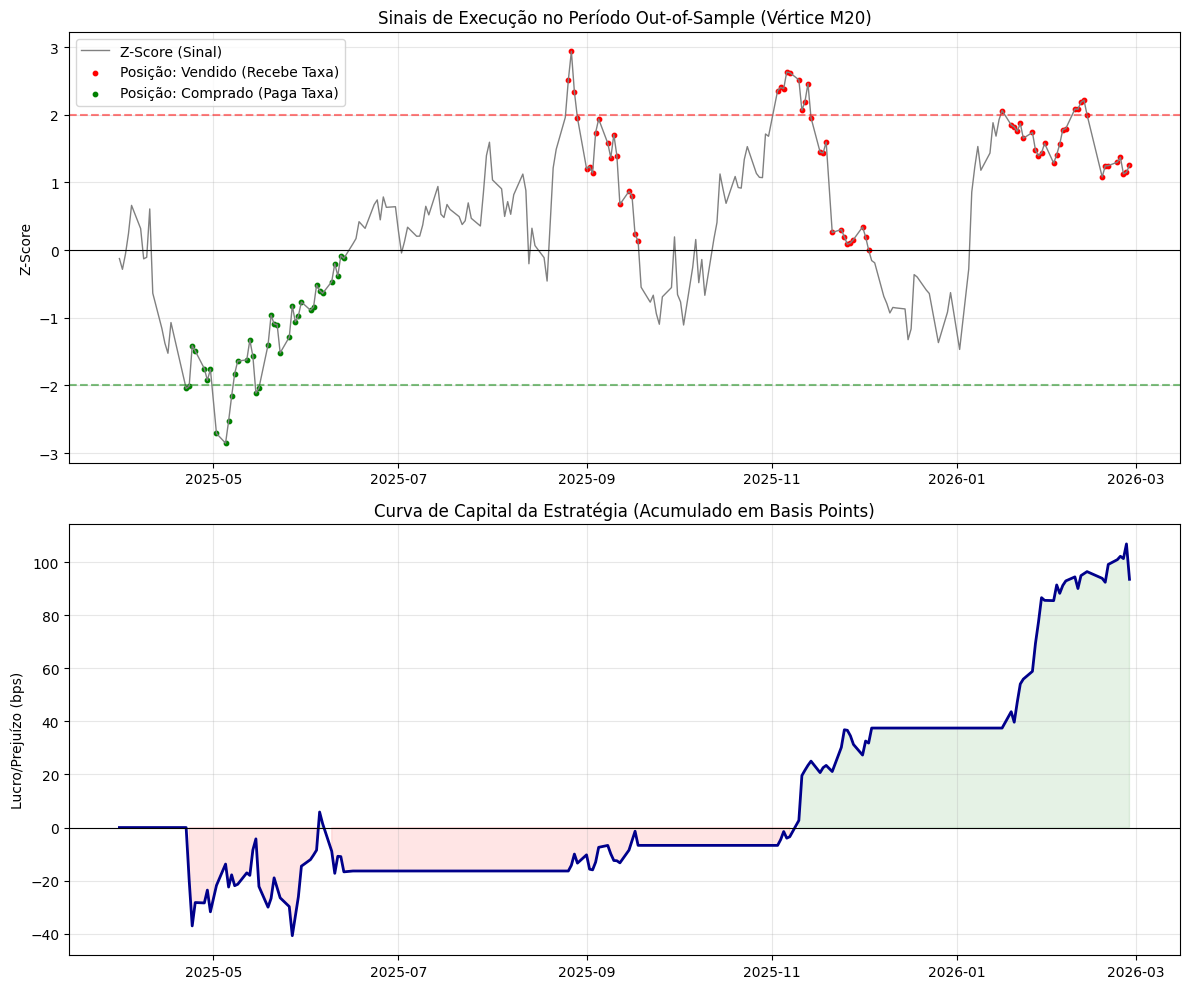


=== RESULTADOS DO BACKTEST (Out-of-Sample) ===
Dias operacionais no teste: 229
Dias posicionado no mercado: 107 dias
Lucro Total Acumulado: 93.56 bps
Maior Lucro (High Watermark): 106.89 bps
Maior Prejuízo (Drawdown Máximo Absoluto): -40.76 bps


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Vamos operar o vértice de 1 ano (M12), onde há muita liquidez e distorções interessantes
vertice_alvo = 'M20'
data_corte = '2024-12-31' # Fim do Treino, Início do Teste

# Separar os dados em Treino e Teste
df_treino = df_pivot.loc[:data_corte].copy()
df_teste = df_pivot.loc[data_corte:].copy() # Inclui o último dia do treino para o diff não dar NaN

print(f"Treinando o modelo com dados até {data_corte}...")
# Treinando o PCA (Apenas no Passado!)
df_diff_treino = df_treino.diff().dropna()
pca = PCA(n_components=3)
pca.fit(df_diff_treino)



#Projetar a Teoria no período de Teste
df_diff_teste = df_teste.diff().dropna()
fatores_teste = pca.transform(df_diff_teste)
diff_teorica_teste = pca.inverse_transform(fatores_teste)

# Reconstruir a taxa teórica no teste
df_teorica_teste = pd.DataFrame(diff_teorica_teste, index=df_diff_teste.index, columns=df_diff_teste.columns).cumsum() + df_teste.iloc[0]

# Calculando o Spread e o Z-Score (com janela móvel dentro do teste)
spread_teste = df_teste.loc[df_teorica_teste.index, vertice_alvo] - df_teorica_teste[vertice_alvo]

window = 60
z_score = (spread_teste - spread_teste.rolling(window).mean()) / spread_teste.rolling(window).std()
z_score = z_score.dropna()


posicao = 0  # 0 = Neutro, 1 = Comprado em Taxa (Paga pré), -1 = Vendido em Taxa (Recebe pré)
historico_posicoes = []
pnl_diario = []

# Taxa real da B3 no período de teste
taxas_reais = df_teste.loc[z_score.index, vertice_alvo]

for i in range(1, len(z_score)):
    hoje = z_score.index[i]
    ontem = z_score.index[i-1]
    
    z_hoje = z_score.loc[hoje]
    z_ontem = z_score.loc[ontem]
    
    taxa_hoje = taxas_reais.loc[hoje]
    taxa_ontem = taxas_reais.loc[ontem]
    
    # Calcular o PnL diário se estivermos posicionados
    # Se Pos = 1 (Comprado em taxa): Ganha se a taxa subir (hoje - ontem é positivo)
    # Se Pos = -1 (Vendido em taxa): Ganha se a taxa cair (hoje - ontem é negativo)
    # Multiplicamos por 100 para transformar em Basis Points (bps)
    retorno_diario = posicao * (taxa_hoje - taxa_ontem) * 100
    pnl_diario.append(retorno_diario)
    
    # REGRAS DE ENTRADA E SAÍDA
    if posicao == 0:
        if z_hoje > 2.0:
            posicao = -1 # Taxa cara demais -> Vender
        elif z_hoje < -2.0:
            posicao = 1  # Taxa barata demais -> Comprar
            
    elif posicao == -1: # Estava vendido
        if z_hoje < 0:  # Reverteu pra média (cruzou o zero) -> Zerar
            posicao = 0
            
    elif posicao == 1:  # Estava comprado
        if z_hoje > 0:  # Reverteu pra média (cruzou o zero) -> Zerar
            posicao = 0
            
    historico_posicoes.append(posicao)

# Adiciona um zero inicial para o primeiro dia (que não tem PnL)
pnl_diario.insert(0, 0)
historico_posicoes.insert(0, 0)

# Criar DataFrame de Resultados
df_resultados = pd.DataFrame({
    'Z-Score': z_score,
    'Posicao': historico_posicoes,
    'PnL_Diario_bps': pnl_diario
}, index=z_score.index)

df_resultados['PnL_Acumulado_bps'] = df_resultados['PnL_Diario_bps'].cumsum()

# PLOTAR OS RESULTADOS DO BACKTEST
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]})

# Gráfico: Dinâmica do Z-Score e as Operações
ax1.plot(df_resultados.index, df_resultados['Z-Score'], color='gray', linewidth=1, label='Z-Score (Sinal)')
ax1.axhline(2, color='red', linestyle='--', alpha=0.5)
ax1.axhline(-2, color='green', linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=0.8)

# Pontos onde o robô estava posicionado
vendidos = df_resultados[df_resultados['Posicao'] == -1]
comprados = df_resultados[df_resultados['Posicao'] == 1]
ax1.scatter(vendidos.index, vendidos['Z-Score'], color='red', s=10, label='Posição: Vendido (Recebe Taxa)')
ax1.scatter(comprados.index, comprados['Z-Score'], color='green', s=10, label='Posição: Comprado (Paga Taxa)')

ax1.set_title(f'Sinais de Execução no Período Out-of-Sample (Vértice {vertice_alvo})')
ax1.set_ylabel('Z-Score')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Gráfico: Curva de Capital (PnL Acumulado)
ax2.plot(df_resultados.index, df_resultados['PnL_Acumulado_bps'], color='darkblue', linewidth=2)
ax2.fill_between(df_resultados.index, df_resultados['PnL_Acumulado_bps'], 0, where=(df_resultados['PnL_Acumulado_bps'] > 0), color='green', alpha=0.1)
ax2.fill_between(df_resultados.index, df_resultados['PnL_Acumulado_bps'], 0, where=(df_resultados['PnL_Acumulado_bps'] < 0), color='red', alpha=0.1)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title(f'Curva de Capital da Estratégia (Acumulado em Basis Points)')
ax2.set_ylabel('Lucro/Prejuízo (bps)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
import os
if not os.path.exists('Figures'):
    os.makedirs('Figures')
plt.savefig('Figures/backtest_pnl.png')
plt.show()

# Estatísticas Finais
print("\n=== RESULTADOS DO BACKTEST (Out-of-Sample) ===")
print(f"Dias operacionais no teste: {len(df_resultados)}")
print(f"Dias posicionado no mercado: {len(vendidos) + len(comprados)} dias")
print(f"Lucro Total Acumulado: {df_resultados['PnL_Acumulado_bps'].iloc[-1]:.2f} bps")
print(f"Maior Lucro (High Watermark): {df_resultados['PnL_Acumulado_bps'].max():.2f} bps")
print(f"Maior Prejuízo (Drawdown Máximo Absoluto): {df_resultados['PnL_Acumulado_bps'].min():.2f} bps")

In [39]:
# 1. CRIAMOS O ACUMULADOR GERAL ANTES DO LOOP
soma_lucro_geral = 0
total_operacoes_geral = 0

for vertice_alvo in vertices_alvo:
    
    print(f"\n{'='*50}")
    print(f"=== ANÁLISE DO VÉRTICE: {vertice_alvo} ===")
    print(f"{'='*50}")

    # Atenção: Certifique-se de que o df_resultados está a ser calculado/atualizado 
    # para CADA vertice_alvo dentro deste loop antes desta linha!
    
    # Identificar todas as operações individuais realizadas
    trades = []
    entrada_taxa = 0
    tipo_trade = ''

    taxas_reais = df_teste.loc[df_resultados.index, vertice_alvo]

    for i in range(1, len(df_resultados)):
        pos_hoje = df_resultados['Posicao'].iloc[i]
        pos_ontem = df_resultados['Posicao'].iloc[i-1]
        
        # Momento de Entrada
        if pos_ontem == 0 and pos_hoje != 0:
            entrada_taxa = taxas_reais.iloc[i]
            tipo_trade = 'Compra (Paga Taxa)' if pos_hoje == 1 else 'Venda (Recebe Taxa)'
            
        # Momento de Saída (Zerar posição)
        elif pos_ontem != 0 and pos_hoje == 0:
            saida_taxa = taxas_reais.iloc[i]
            # PnL = Diferença de taxa multiplicada pela direção da aposta (1 ou -1)
            pnl_trade = pos_ontem * (saida_taxa - entrada_taxa) * 100 
            trades.append({
                'Tipo': tipo_trade,
                'Taxa Entrada (%)': entrada_taxa,
                'Taxa Saida (%)': saida_taxa,
                'Lucro/Prejuízo (bps)': pnl_trade
            })

    df_trades = pd.DataFrame(trades)

    # Calcular os KPIs
    if not df_trades.empty:
        total_trades = len(df_trades)
        trades_vencedores = len(df_trades[df_trades['Lucro/Prejuízo (bps)'] > 0])
        win_rate = (trades_vencedores / total_trades) * 100
        
        lucro_total = df_resultados['PnL_Acumulado_bps'].iloc[-1]
        
        # 2. ADICIONAMOS O LUCRO DESTE VÉRTICE AO ACUMULADOR GERAL
        soma_lucro_geral += lucro_total
        total_operacoes_geral += total_trades
        
        # Cálculo do Max Drawdown
        pico_acumulado = df_resultados['PnL_Acumulado_bps'].cummax()
        drawdown = pico_acumulado - df_resultados['PnL_Acumulado_bps']
        max_drawdown = drawdown.max()
        
        media_ganhos = df_trades[df_trades['Lucro/Prejuízo (bps)'] > 0]['Lucro/Prejuízo (bps)'].mean()
        media_perdas = df_trades[df_trades['Lucro/Prejuízo (bps)'] < 0]['Lucro/Prejuízo (bps)'].mean()
        payoff = abs(media_ganhos / media_perdas) if pd.notna(media_perdas) and media_perdas != 0 else float('inf')

        # Imprimir o Boletim do Vértice
        print(f"1. Total de Operações Realizadas: {total_trades}")
        print(f"2. Taxa de Acerto (Win Rate): {win_rate:.1f}%")
        print(f"3. Lucro Total Acumulado: {lucro_total:.1f} bps")
        print(f"4. Rebaixamento Máximo (Max Drawdown): {max_drawdown:.1f} bps")
        print(f"5. Payoff (Ganha/Perde): {payoff:.2f}")
        
        print("\n=> HISTÓRICO DE BOLETAS (TRADES):")
        pd.set_option('display.float_format', '{:.3f}'.format)
        print(df_trades)
    else:
        print(f"Nenhuma operação foi acionada para o vértice {vertice_alvo} no período de teste Out-of-Sample.")

# 3. IMPRIMIR O RESUMO GERAL DA CARTEIRA FORA DO LOOP
print(f"\n\n{'*'*50}")
print(f"********** RESUMO GERAL DA ESTRATÉGIA **********")
print(f"{'*'*50}")
print(f"-> Total de Vértices Operados: {len(vertices_alvo)}")
print(f"-> Total de Operações na Curva: {total_operacoes_geral}")
print(f"-> LUCRO TOTAL ACUMULADO (CARTEIRA): {soma_lucro_geral:.1f} bps")
print(f"{'*'*50}\n")


=== ANÁLISE DO VÉRTICE: M1 ===
1. Total de Operações Realizadas: 3
2. Taxa de Acerto (Win Rate): 100.0%
3. Lucro Total Acumulado: 93.6 bps
4. Rebaixamento Máximo (Max Drawdown): 40.8 bps
5. Payoff (Ganha/Perde): inf

=> HISTÓRICO DE BOLETAS (TRADES):
                  Tipo  Taxa Entrada (%)  Taxa Saida (%)  Lucro/Prejuízo (bps)
0   Compra (Paga Taxa)            13.656          14.039                38.256
1  Venda (Recebe Taxa)            14.908          14.901                 0.685
2  Venda (Recebe Taxa)            14.084          13.386                69.808

=== ANÁLISE DO VÉRTICE: M2 ===
1. Total de Operações Realizadas: 3
2. Taxa de Acerto (Win Rate): 66.7%
3. Lucro Total Acumulado: 93.6 bps
4. Rebaixamento Máximo (Max Drawdown): 40.8 bps
5. Payoff (Ganha/Perde): 1.23

=> HISTÓRICO DE BOLETAS (TRADES):
                  Tipo  Taxa Entrada (%)  Taxa Saida (%)  Lucro/Prejuízo (bps)
0   Compra (Paga Taxa)            13.898          14.438                54.021
1  Venda (Recebe Taxa)

## robustez

In [ ]:
import pandas as pd
import numpy as np

# ESCOLHA AQUI O VÉRTICE VENCEDOR DO SEU ARTIGO (ex: M20, M12)
vertice_alvo = 'M20' 

print(f"Iniciando Análise de Sensibilidade (Out-of-Sample) para o Vértice {vertice_alvo}...\n")

cenarios = [
    {'z_thresh': 2.0, 'window': 60},  # O seu modelo Base
    {'z_thresh': 2.0, 'window': 40},  # Janela mais curta 
    {'z_thresh': 2.0, 'window': 120}, # Janela mais longa 
    {'z_thresh': 1.5, 'window': 60},  # Gatilho mais sensível 
    {'z_thresh': 2.5, 'window': 60}   # Gatilho mais conservador 
]

resultados_robustez = []

# Calcular o spread do Teste apenas para este vértice
spread_teste = df_teste.loc[df_teorica_teste.index, vertice_alvo] - df_teorica_teste[vertice_alvo]
taxas_reais = df_teste.loc[spread_teste.index, vertice_alvo]

for cenario in cenarios:
    w = cenario['window']
    z_t = cenario['z_thresh']
    
    # Recalcular Z-Score para a janela do cenário
    z_score = (spread_teste - spread_teste.rolling(w).mean()) / spread_teste.rolling(w).std()
    z_score = z_score.dropna()
    
    posicao = 0
    entrada_taxa = 0
    pnl_diario = [0]
    trades = []
    
    datas = z_score.index
    
    for i in range(1, len(datas)):
        hoje = datas[i]
        ontem = datas[i-1]
        
        z_hoje = z_score.loc[hoje]
        taxa_hoje = taxas_reais.loc[hoje]
        taxa_ontem = taxas_reais.loc[ontem]
        
        # PnL Diário
        retorno_diario = posicao * (taxa_hoje - taxa_ontem) * 100
        pnl_diario.append(retorno_diario)
        
        # Regras
        if posicao == 0:
            if z_hoje > z_t:
                posicao = -1 
                entrada_taxa = taxa_hoje
            elif z_hoje < -z_t:
                posicao = 1  
                entrada_taxa = taxa_hoje
                
        elif posicao == -1 and z_hoje < 0: 
            trades.append(-1 * (taxa_hoje - entrada_taxa) * 100)
            posicao = 0
            
        elif posicao == 1 and z_hoje > 0:  
            trades.append(1 * (taxa_hoje - entrada_taxa) * 100)
            posicao = 0

    # KPIs do Cenário
    serie_pnl = pd.Series(pnl_diario)
    pnl_acumulado = serie_pnl.cumsum()
    total_pnl = pnl_acumulado.iloc[-1] if not pnl_acumulado.empty else 0
    
    if not pnl_acumulado.empty:
        picos = pnl_acumulado.cummax()
        drawdown = picos - pnl_acumulado
        max_dd = drawdown.max()
    else:
        max_dd = 0
        
    num_trades = len(trades)
    hit_rate = (sum(1 for t in trades if t > 0) / num_trades * 100) if num_trades > 0 else 0
    
    nome_cenario = f"|Z| > {z_t} | w={w}"
    if z_t == 2.0 and w == 60:
        nome_cenario += " (Base)"
        
    resultados_robustez.append({
        'Configuração': nome_cenario,
        'PnL (bps)': total_pnl,
        'Max DD (bps)': -max_dd, 
        'Hit Rate (%)': hit_rate,
        'Nº Trades': num_trades
    })

df_tabela5 = pd.DataFrame(resultados_robustez)
pd.set_option('display.float_format', '{:.1f}'.format)
print(df_tabela5.to_string(index=False))    

Iniciando Análise de Sensibilidade (Out-of-Sample) para o Vértice M20...

           Configuração  PnL (bps)  Max DD (bps)  Hit Rate (%)  Nº Trades
|Z| > 2.0 | w=60 (Base)       93.6         -40.8          66.7          3
       |Z| > 2.0 | w=40      128.6         -36.5         100.0          4
      |Z| > 2.0 | w=120       56.0         -44.3         100.0          1
       |Z| > 1.5 | w=60      119.5         -40.8          75.0          4
       |Z| > 2.5 | w=60       56.6         -36.5         100.0          3


## sla

In [41]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Certifique-se de que já rodou o PCA no df_treino antes disto!
# Reconstruir a curva teórica no Treino (In-Sample)
fatores_treino = pca.transform(df_diff_treino)
diff_teorica_treino = pca.inverse_transform(fatores_treino)
df_teorica_treino = pd.DataFrame(diff_teorica_treino, index=df_diff_treino.index, columns=df_diff_treino.columns).cumsum() + df_treino.iloc[0]

# Vértices que vamos colocar na Tabela
vertices_analise = ['M6', 'M12', 'M24']
resultados_tabela = []

print("Calculando Estatísticas da Tabela 3 (In-Sample)...\n")

for v in vertices_analise:
    # 1. Calcular o Spread do Treino (Real B3 - Teórico PCA)
    spread_in = df_treino.loc[df_teorica_treino.index, v] - df_teorica_treino[v]
    
    # 2. Regressão OLS para Meia-Vida (Ornstein-Uhlenbeck)
    y = spread_in.diff().dropna()
    X = spread_in.shift(1).dropna()
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    theta = -model.params[v]
    if theta > 0:
        meia_vida = np.log(2) / theta
    else:
        meia_vida = np.nan # Se não houver reversão
        
    # 3. Desvio Padrão do Spread (em basis points)
    sigma_bps = spread_in.std() * 100
    
    # 4. Cálculo do Z-Score e da Frequência de Extremos
    window = 60
    z_score_in = (spread_in - spread_in.rolling(window).mean()) / spread_in.rolling(window).std()
    z_score_in = z_score_in.dropna()
    
    pct_extremos = (abs(z_score_in) > 2).mean() * 100
    
    # Guardar os resultados
    resultados_tabela.append({
        'Vértice': v,
        'Meia-vida (dias)': meia_vida,
        'Sigma (bps)': sigma_bps,
        '% (|Z| > 2)': pct_extremos
    })

# Exibir a Tabela Pronta
df_tabela3 = pd.DataFrame(resultados_tabela)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df_tabela3)

Calculando Estatísticas da Tabela 3 (In-Sample)...

  Vértice  Meia-vida (dias)  Sigma (bps)  % (|Z| > 2)
0      M6           1119.80        68.86        16.51
1     M12            140.82        24.85        13.08
2     M24            299.80        19.72        12.97


P-Value (ADF): 0.8004
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0004
Meia-Vida (Half-Life): 1749.4 dias úteis
P-Value (ADF): 0.3794
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0025
Meia-Vida (Half-Life): 281.3 dias úteis
P-Value (ADF): 0.4810
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0004
Meia-Vida (Half-Life): 1799.8 dias úteis
P-Value (ADF): 0.7463
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0003
Meia-Vida (Half-Life): 2747.3 dias úteis
P-Value (ADF): 0.6998
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0003
Meia-Vida (Half-Life): 2336.7 dias úteis
P-Value (ADF): 0.7397
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0004
Meia-Vida (Half-Life): 1579.8 dias úteis
P-Value (ADF): 0.7658
-> Série não estacionária a 95% 
Velocidade de Reversão (Theta): 0.0005
Meia-Vida (Half-Life): 1428.4 dias úteis
P-Value (ADF): 0.7734
-> Série não estacionária a 95% 
V

C:\Users\Adrian\AppData\Local\Temp\ipykernel_5604\769558288.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


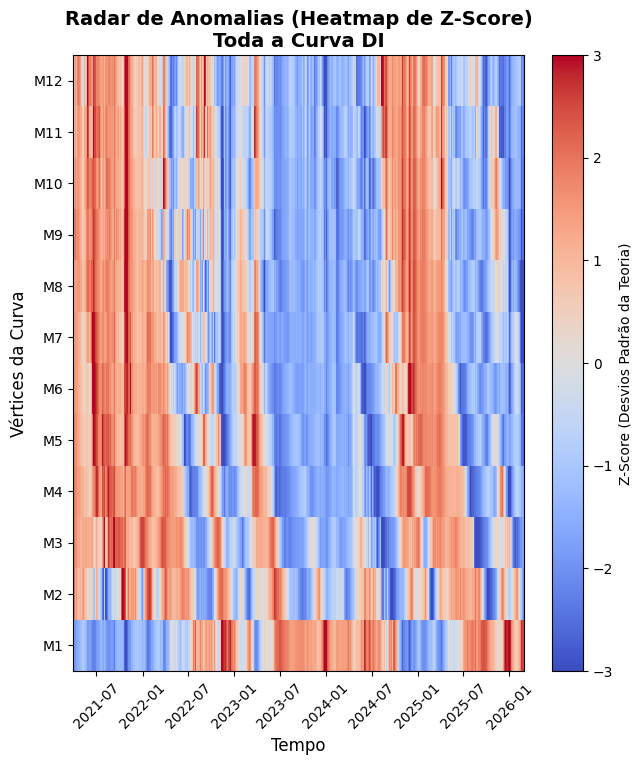

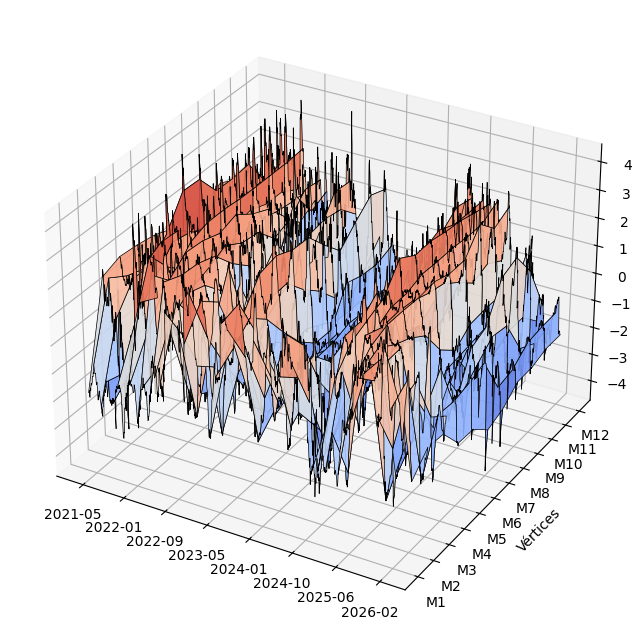

In [42]:

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller


for vertice_alvo in vertices_alvo:
    # ORNSTEIN-UHLENBECK
    spread_alvo = df_spreads[vertice_alvo]
    series = spread_alvo.dropna()

    # Teste ADF (Estacionariedade)
    adf_result = adfuller(series)
    print(f"P-Value (ADF): {adf_result[1]:.4f}")
    if adf_result[1] < 0.05:
        print("-> SÉRIE ESTACIONÁRIA! (Pode Operar)")
    else:
        print("-> Série não estacionária a 95% ")

    # Regressão OLS para achar Theta
    y = series.diff().dropna()
    X = series.shift(1).dropna()
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()


    theta = -model.params[vertice_alvo]
    if theta > 0:
        half_life = np.log(2) / theta
        print(f"Velocidade de Reversão (Theta): {theta:.4f}")
        print(f"Meia-Vida (Half-Life): {half_life:.1f} dias úteis")
    else:
        print("-> Erro: Theta negativo (série explosiva).")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Calcular o Z-Score para TODOS os vértices ao mesmo tempo (O Radar completo)
window = 60

vertices_alvo = ['M1','M2','M3','M4','M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
df_spreads = df_spreads[vertices_alvo]
# Z = (Valor - Média da Janela) / Desvio Padrão da Janela
df_zscores = (df_spreads - df_spreads.rolling(window).mean()) / df_spreads.rolling(window).std()

# Limpar os NaNs gerados pela janela móvel inicial (os primeiros 60 dias)
df_z_clean = df_zscores.dropna()

# 3. Preparar os eixos para o gráfico 3D e Heatmap
# Eixo X = Datas, Eixo Y = Número do Vértice (1 a 15), Eixo Z = Valor do Z-Score
X_dates = df_z_clean.index
Y_verts = np.arange(1, len(df_z_clean.columns) + 1)
X, Y = np.meshgrid(mdates.date2num(X_dates), Y_verts)
Z = df_z_clean.T.values

# 4. Criar a figura com as duas visualizações (Lado a Lado)
fig = plt.figure(figsize=(16,8))

# --- GRÁFICO 1: Heatmap (O Mapa de Calor da Mesa de Operações) ---
ax1 = fig.add_subplot(121)
# Usando cmap 'coolwarm': Vermelho = Z>0 (Venda), Azul = Z<0 (Compra)
im = ax1.pcolormesh(X_dates, Y_verts, Z, cmap='coolwarm', vmin=-3, vmax=3, shading='auto')
ax1.set_yticks(Y_verts)
ax1.set_yticklabels(df_z_clean.columns)
ax1.set_title('Radar de Anomalias (Heatmap de Z-Score)\nToda a Curva DI', fontsize=14, fontweight='bold')
ax1.set_ylabel('Vértices da Curva', fontsize=12)
ax1.set_xlabel('Tempo', fontsize=12)
# Formatar o eixo X para mostrar as datas bonitinhas
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
fig.colorbar(im, ax=ax1, label='Z-Score (Desvios Padrão da Teoria)')



from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', vmin=-3, vmax=3, linewidth=0.5, edgecolors='k', alpha=0.9)
ax.set_yticks(Y_verts)
ax.set_yticklabels(df_z_clean.columns)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
#ax.set_title('Superfície 3D de Distorções da Curva', fontsize=14, fontweight='bold')
ax.set_ylabel('Vértices')
ax.set_zlabel('Z-Score')
fig.tight_layout()
plt.savefig('Figures/superficie.png', dpi=300, bbox_inches='tight')
plt.show()

## SLA @

A calcular o PnL individual para mapeamento da Curva DI (166 vértices)...


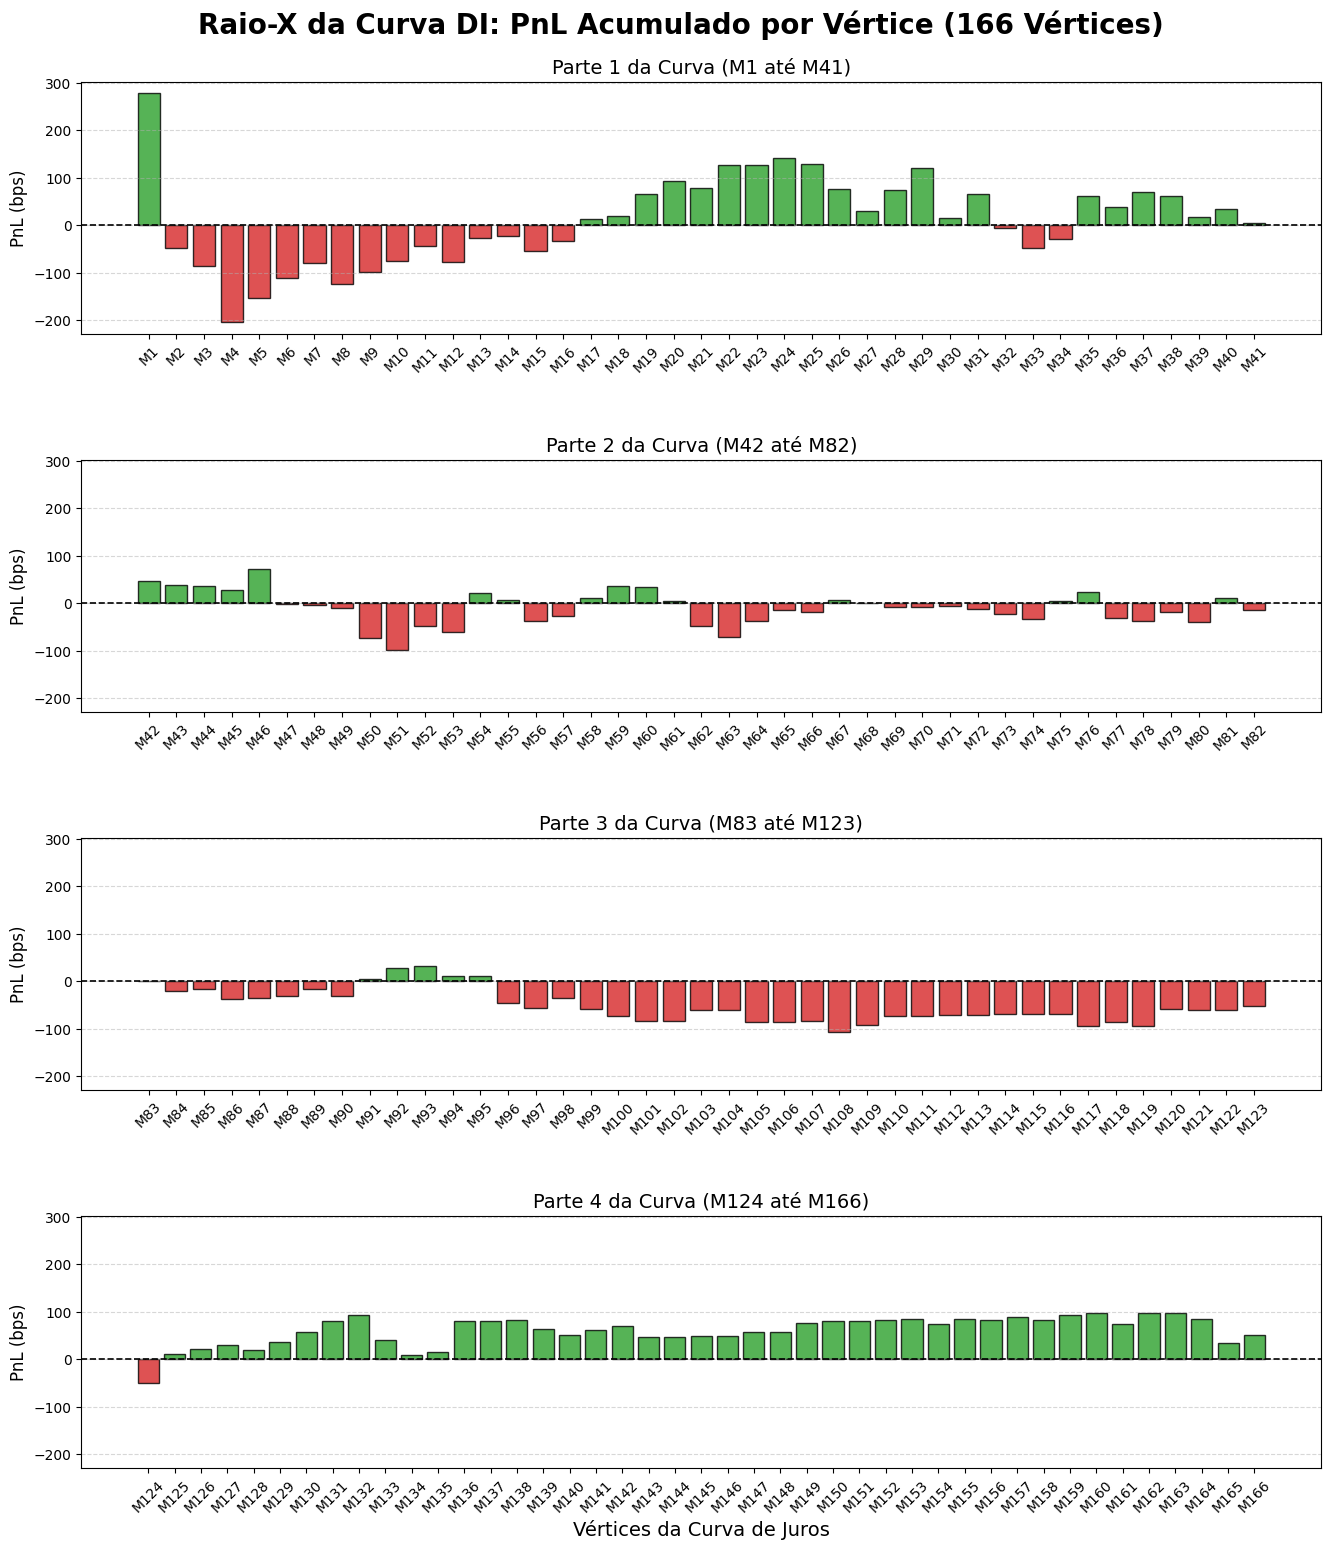

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("A calcular o PnL individual para mapeamento da Curva DI (166 vértices)...")

# Parâmetros do seu modelo Base
w = 60
z_t = 2.0

# Dicionário para guardar o lucro/prejuízo final de cada vértice
pnl_por_vertice = {}

# Pega em todos os vértices (presumindo que são 166)
vertices_alvo = df_teste.columns 

for vertice in vertices_alvo:
    # 1. Calcular o spread do Teste apenas para o vértice atual
    spread_teste = df_teste[vertice] - df_teorica_teste[vertice]
    taxas_reais = df_teste[vertice]
    
    # 2. Recalcular o Z-Score
    z_score = (spread_teste - spread_teste.rolling(w).mean()) / spread_teste.rolling(w).std()
    z_score = z_score.dropna()
    
    posicao = 0
    pnl_acumulado = 0
    
    datas = z_score.index
    
    # 3. Simulação da boleta
    for i in range(1, len(datas)):
        hoje = datas[i]
        ontem = datas[i-1]
        
        z_hoje = z_score.loc[hoje]
        taxa_hoje = taxas_reais.loc[hoje]
        taxa_ontem = taxas_reais.loc[ontem]
        
        # Marcação a mercado diária
        pnl_acumulado += posicao * (taxa_hoje - taxa_ontem) * 100
        
        # Regras de Trading
        if posicao == 0:
            if z_hoje > z_t:
                posicao = -1 
            elif z_hoje < -z_t:
                posicao = 1  
        elif posicao == -1 and z_hoje < 0: 
            posicao = 0
        elif posicao == 1 and z_hoje > 0:  
            posicao = 0
            
    # 4. Guardar o PnL final do vértice
    pnl_por_vertice[vertice] = pnl_acumulado

serie_pnl = pd.Series(pnl_por_vertice)

# ==========================================
# PLOT DO GRÁFICO DIVIDIDO EM 4 PAINÉIS
# ==========================================

# Dividir a série em 4 pedaços (aproximadamente 41 ou 42 vértices cada)
n_splits = 4
tamanho_fatia = len(serie_pnl) // n_splits
fatias = [serie_pnl.iloc[i * tamanho_fatia : (i + 1) * tamanho_fatia] for i in range(n_splits)]
# Adicionar o resto à última fatia, se houver
if len(serie_pnl) % n_splits != 0:
    fatias[-1] = serie_pnl.iloc[(n_splits - 1) * tamanho_fatia :]

# Criar a figura com 4 linhas (subplots)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(16, 18), sharey=True)
fig.suptitle('Raio-X da Curva DI: PnL Acumulado por Vértice (166 Vértices)', fontsize=20, fontweight='bold', y=0.92)

for i, ax in enumerate(axes):
    dados_fatia = fatias[i]
    
    # Cores condicionais (Verde para lucro, Vermelho para prejuízo)
    cores = ['#2ca02c' if val > 0 else '#d62728' for val in dados_fatia.values]
    
    # Criar as barras para esta fatia
    ax.bar(dados_fatia.index, dados_fatia.values, color=cores, edgecolor='black', alpha=0.8)
    
    # Formatação de cada painel
    ax.set_ylabel('PnL (bps)', fontsize=12)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Título indicando que parte da curva estamos a ver
    ax.set_title(f'Parte {i+1} da Curva ({dados_fatia.index[0]} até {dados_fatia.index[-1]})', fontsize=14)

plt.xlabel('Vértices da Curva de Juros', fontsize=14)
plt.subplots_adjust(hspace=0.5) # Espaço vertical entre os gráficos para os rótulos não se sobreporem

plt.savefig('grafico_pnl_4_paineis.png', dpi=300, bbox_inches='tight')
plt.show()